# SRA Regulatory Risk Intelligence  
## 02 — Exploratory Analysis

This notebook explores the **126 unique regulatory decisions** produced by the cleaning pipeline in Notebook 01.

### Analytical questions
1. What decision categories appear most often in this dataset?
2. How are decisions distributed over time?
3. Which regulated names appear more than once?
4. Which decisions persisted across multiple downloaded snapshots?
5. What descriptive patterns may be useful for later regulatory-risk modelling?

> **Important:** This is a descriptive portfolio analysis of the downloaded snapshots. It is **not** an official SRA risk assessment, and frequencies in this sample should not be interpreted as the full population of SRA enforcement activity.


## 1. Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


## 2. Load the cleaned master dataset

In [2]:
DATA_PATH = Path("../data/processed/sra_decisions_clean.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print(f"Rows: {len(df):,}")
print(f"Decision categories: {df['Decision'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Rows: 126
Decision categories: 11
Date range: 2026-06-25 to 2026-08-27


,Name,SRA_ID,Decision,Date,Profile_URL,Snapshot_Appearances
0,Akbar Ifzal Ali,571258.0,Decisions to refer to SDT,2026-08-27,https://www.sra.org.uk/consumers/solicitor-check/571258/,2
1,Emma Rowe,279936.0,Decisions to refer to SDT,2026-08-27,https://www.sra.org.uk/consumers/solicitor-check/279936/,2
2,Heather Joan Roberts,393573.0,Condition,2026-08-26,https://www.sra.org.uk/consumers/solicitor-check/393573/,2
3,Azair Mahmood Alam,334162.0,Intervention,2026-08-25,https://www.sra.org.uk/consumers/solicitor-check/334162/,2
4,Lewis Duncan - 3,782329.0,Control of non-qualified staff (section 43/99 order),2026-08-25,https://www.sra.org.uk/consumers/solicitor-check/7823293/,2


## 3. Decision-category distribution

In [3]:
decision_counts = (
    df["Decision"]
    .value_counts()
    .rename_axis("Decision")
    .reset_index(name="Count")
)

decision_counts["Share_Percent"] = (
    decision_counts["Count"] / len(df) * 100
).round(1)

decision_counts


,Decision,Count,Share_Percent
0,Condition,31,24.6
1,Regulatory settlement agreement,21,16.7
2,Intervention,20,15.9
3,Decisions to refer to SDT,16,12.7
4,Control of non-qualified staff (section 43/99 order),12,9.5
5,Fine,11,8.7
6,Solicitors Disciplinary Tribunal order,6,4.8
7,Rebuke,4,3.2
8,Termination of suspension of PC/registration,3,2.4
9,Approval of employment (section 43),1,0.8


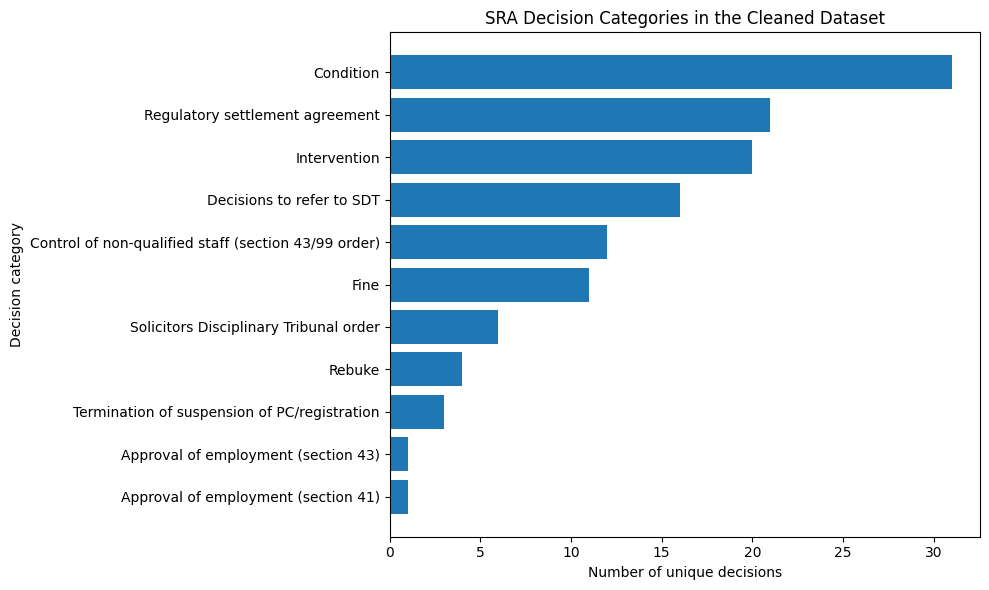

In [4]:
plot_data = decision_counts.sort_values("Count")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Decision"], plot_data["Count"])
plt.title("SRA Decision Categories in the Cleaned Dataset")
plt.xlabel("Number of unique decisions")
plt.ylabel("Decision category")
plt.tight_layout()
plt.show()


### Interpretation

The chart shows the **composition of this downloaded sample**, not the probability that any particular outcome occurs in the wider SRA system. Categories with larger counts are simply more represented in the snapshots available for this project.


## 4. Decisions over time

In [5]:
monthly_counts = (
    df.assign(Month=df["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month")
    .size()
    .reset_index(name="Decision_Count")
)

monthly_counts.tail(12)


,Month,Decision_Count
0,2026-06-01,16
1,2026-07-01,77
2,2026-08-01,33


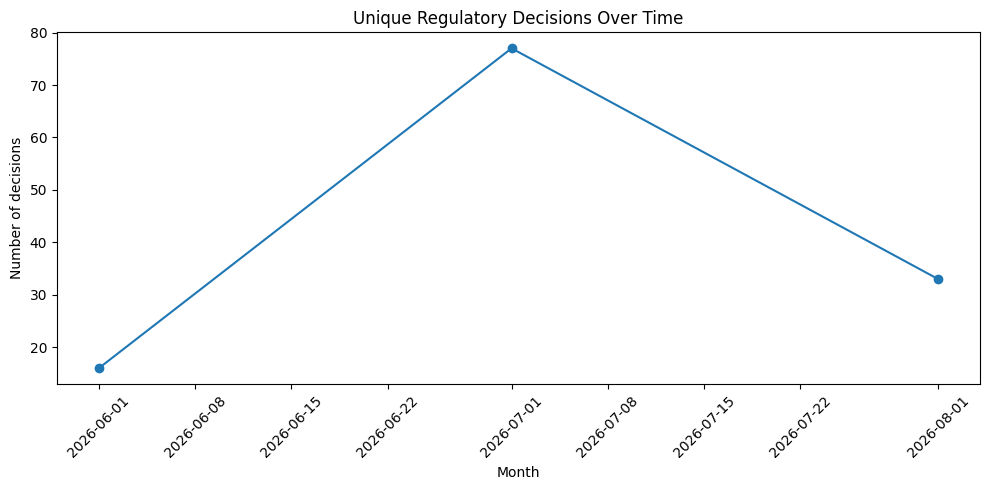

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_counts["Month"], monthly_counts["Decision_Count"], marker="o")
plt.title("Unique Regulatory Decisions Over Time")
plt.xlabel("Month")
plt.ylabel("Number of decisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretation

Monthly variation may reflect actual enforcement timing, publication timing, or the way the snapshots were collected. For that reason, the time series is useful as a descriptive view, but it should not be treated as evidence of a causal trend without a more complete source dataset.


## 5. Most frequently appearing regulated names

In [7]:
name_counts = (
    df["Name"]
    .value_counts()
    .rename_axis("Name")
    .reset_index(name="Decision_Count")
)

repeat_names = name_counts[name_counts["Decision_Count"] > 1].copy()

print(f"Names with more than one unique decision: {len(repeat_names)}")
repeat_names.head(15)


Names with more than one unique decision: 18


,Name,Decision_Count
0,Emenike Mgbemena,3
1,Paul Harfitt,2
2,Jay Allan Tooker,2
3,Ukamaka Okafor,2
4,William John Gregory Osmond,2
5,Richard Jefferies,2
6,Richard John Tinkler,2
7,Charsley Harrison LLP,2
8,Sayers Solicitors LLP,2
9,Robert Bradshaw,2


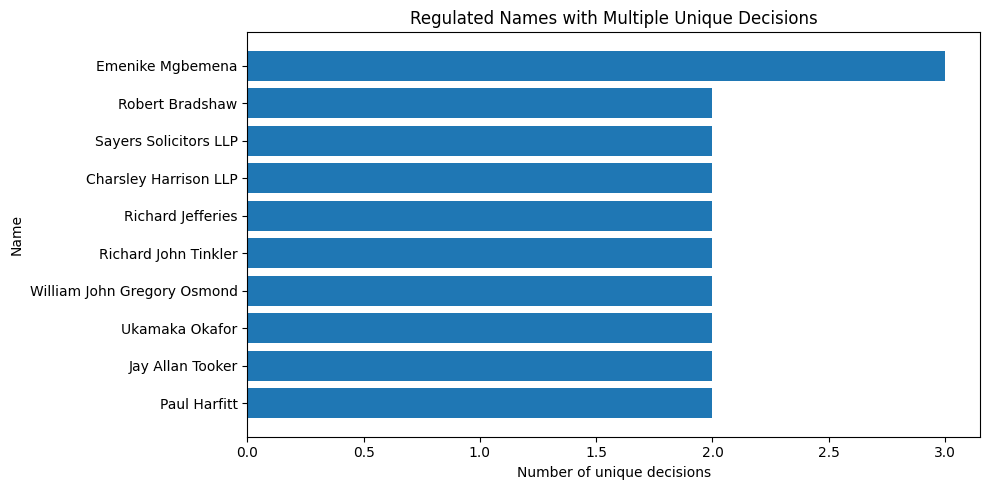

In [8]:
top_repeat = repeat_names.head(10).sort_values("Decision_Count")

if len(top_repeat) > 0:
    plt.figure(figsize=(10, 5))
    plt.barh(top_repeat["Name"], top_repeat["Decision_Count"])
    plt.title("Regulated Names with Multiple Unique Decisions")
    plt.xlabel("Number of unique decisions")
    plt.ylabel("Name")
    plt.tight_layout()
    plt.show()
else:
    print("No regulated name appears in more than one unique decision.")


### Interpretation

A repeated name is a useful signal for further review, but it does **not** by itself establish heightened present-day risk. A name may appear more than once for several reasons, including multiple historical matters or related regulatory actions.


## 6. Snapshot persistence

In [9]:
snapshot_summary = df["Snapshot_Appearances"].describe()
snapshot_summary


count    126.000000
mean       3.571429
std        2.812625
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max        8.000000
Name: Snapshot_Appearances, dtype: float64

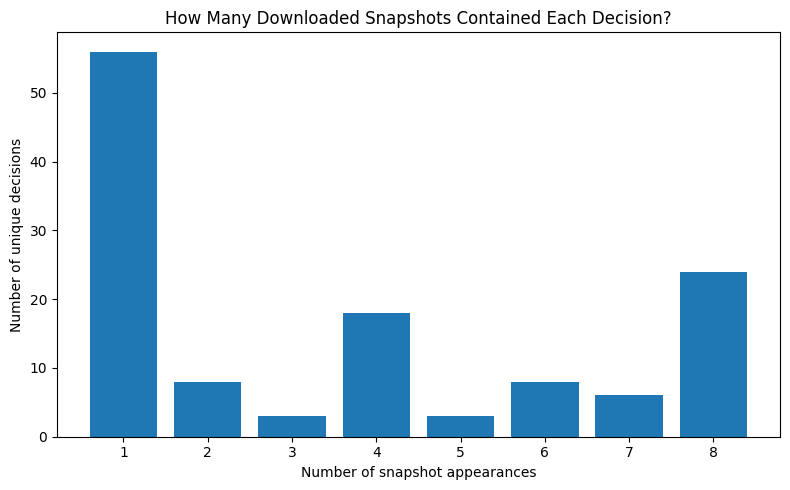

,Snapshot_Appearances,Decision_Count
0,1,56
1,2,8
2,3,3
3,4,18
4,5,3
5,6,8
6,7,6
7,8,24


In [10]:
persistence_counts = (
    df["Snapshot_Appearances"]
    .value_counts()
    .sort_index()
    .rename_axis("Snapshot_Appearances")
    .reset_index(name="Decision_Count")
)

plt.figure(figsize=(8, 5))
plt.bar(persistence_counts["Snapshot_Appearances"], persistence_counts["Decision_Count"])
plt.title("How Many Downloaded Snapshots Contained Each Decision?")
plt.xlabel("Number of snapshot appearances")
plt.ylabel("Number of unique decisions")
plt.tight_layout()
plt.show()

persistence_counts


### Why snapshot persistence matters

The same published decision can remain visible across multiple downloads. That is why Notebook 01 deduplicated the snapshots before analysis.

`Snapshot_Appearances` is retained as a **data-provenance feature**, not as a measure of regulatory severity. A decision appearing in more snapshots does not automatically mean it is more serious.


## 7. Decision categories by year

In [11]:
year_decision = (
    df.assign(Year=df["Date"].dt.year)
    .pivot_table(
        index="Year",
        columns="Decision",
        values="Name",
        aggfunc="count",
        fill_value=0
    )
)

year_decision.tail()


Decision,Approval of employment (section 41),Approval of employment (section 43),Condition,Control of non-qualified staff (section 43/99 order),Decisions to refer to SDT,Fine,Intervention,Rebuke,Regulatory settlement agreement,Solicitors Disciplinary Tribunal order,Termination of suspension of PC/registration
Year,,,,,,,,,,,
2026,1,1,31,12,16,11,20,4,21,6,3


## 8. A compact regulatory-intelligence summary

In [12]:
most_common_decision = decision_counts.iloc[0]["Decision"]
most_common_count = int(decision_counts.iloc[0]["Count"])
repeat_entity_count = int((name_counts["Decision_Count"] > 1).sum())
max_snapshot_appearances = int(df["Snapshot_Appearances"].max())

summary = pd.DataFrame({
    "Metric": [
        "Unique decisions",
        "Decision categories",
        "Most represented category",
        "Count in most represented category",
        "Names with multiple unique decisions",
        "Maximum snapshot appearances for one decision"
    ],
    "Value": [
        len(df),
        df["Decision"].nunique(),
        most_common_decision,
        most_common_count,
        repeat_entity_count,
        max_snapshot_appearances
    ]
})

summary


,Metric,Value
0,Unique decisions,126
1,Decision categories,11
2,Most represented category,Condition
3,Count in most represented category,31
4,Names with multiple unique decisions,18
5,Maximum snapshot appearances for one decision,8


## 9. Exploratory findings

This exploratory stage supports several conclusions about the **dataset itself**:

- the downloaded snapshots contain several distinct regulatory outcome categories;
- repeated publication across snapshots is substantial enough that deduplication is essential;
- some regulated names appear in more than one unique decision;
- decision counts vary over time;
- the data can support a later prototype risk framework, provided the model clearly separates **observed enforcement history** from any claim about current or future regulatory risk.

### Next notebook: 03 — Prototype Regulatory Risk Model

Notebook 03 will translate the legal/regulatory categories into a transparent analytical framework. The model will:

- document the rationale for each severity tier;
- distinguish historical regulatory outcomes from present risk;
- avoid presenting the score as an official SRA measure;
- make all weights visible and editable; and
- test how entity-level scores change when frequency and outcome severity are combined.

This makes the portfolio project useful as a demonstration of **legal reasoning + data analysis + responsible risk modelling** rather than simply producing charts.
